# TT-12 — Ridge Regression (L2)
## Phân bổ ngân sách quảng cáo đa kênh khi các kênh chạy cùng lúc

**Mục tiêu:** dùng Ridge Regression để ổn định hệ số hồi quy khi các kênh quảng cáo
(TV, Facebook, Google) có ngân sách tương quan cao (đa cộng tuyến), từ đó đề xuất
phân bổ ngân sách đáng tin cậy hơn Linear Regression thông thường.


In [1]:
import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

%matplotlib inline

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = ROOT / "data"
REPORTS_DIR = ROOT / "reports"
MODELS_DIR = ROOT / "models"
REPORTS_DIR.mkdir(exist_ok=True, parents=True)
MODELS_DIR.mkdir(exist_ok=True, parents=True)

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)


## 1. Đối chiếu với bộ dữ liệu thật (Kaggle Advertising)

Bộ `advertising.csv` (200 dòng, TV/Radio/Newspaper/Sales) được nộp kèm bài. Ta xem
qua ma trận tương quan trước khi quyết định hướng đi.

In [2]:
real_df = pd.read_csv(DATA_DIR / "advertising.csv")
real_df.columns = [c.strip() for c in real_df.columns]
real_df.describe()


,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


In [3]:
real_corr = real_df.drop(columns=["Sales"]).corr()
real_corr.round(3)


,TV,Radio,Newspaper
TV,1.000,0.055,0.057
Radio,0.055,1.000,0.354
Newspaper,0.057,0.354,1.000


**Nhận xét:** tương quan giữa TV, Radio, Newspaper trong bộ dữ liệu thật đều
rất thấp (≈ 0.05 – 0.35) → bộ này **không có đa cộng tuyến rõ rệt**, nên không phù hợp
để minh hoạ tác dụng cốt lõi của Ridge (ổn định hệ số khi các biến tương quan cao).

Theo khuyến nghị ở mục 3 của README, ta **tự sinh dữ liệu mô phỏng có đa cộng tuyến
chủ đích** (ngân sách Facebook được đặt tỉ lệ thuận với ngân sách TV, giống tình huống
thực tế "chiến dịch lớn thì bơm tiền tất cả kênh cùng lúc") để thấy rõ hiệu ứng Ridge.


## 2. Sinh dữ liệu mô phỏng có đa cộng tuyến

In [4]:
n = 500
tv = rng.uniform(50, 500, n)
fb = tv * 0.6 + rng.normal(0, 15, n)      # tương quan cao với TV (r ~ 0.95-0.98)
gg = rng.uniform(20, 300, n)
doanh_thu = 3.2 * tv + 1.8 * fb + 2.5 * gg + rng.normal(0, 50, n)

df = pd.DataFrame({"TV": tv, "Facebook": fb, "Google": gg, "DoanhThu": doanh_thu})
feature_cols = ["TV", "Facebook", "Google"]
target_col = "DoanhThu"
X = df[feature_cols]
y = df[target_col]
df.head()


,TV,Facebook,Google,DoanhThu
0,398.280222,260.466351,115.959820,2023.697668
1,247.495298,149.869981,69.625940,1227.675821
2,436.369064,270.533095,209.866337,2512.806355
3,363.815613,217.437620,256.882117,2124.946075
4,92.379807,52.871770,31.271047,449.428305


## 3. Ma trận tương quan + bảng VIF

VIF (Variance Inflation Factor) > 10 là dấu hiệu đa cộng tuyến nghiêm trọng.

In [5]:
corr = X.corr()
corr.round(3)


,TV,Facebook,Google
TV,1.000,0.981,0.016
Facebook,0.981,1.000,0.011
Google,0.016,0.011,1.000


In [6]:
def compute_vif(X: pd.DataFrame) -> pd.DataFrame:
    X_const = X.copy()
    X_const.insert(0, "const", 1.0)
    rows = []
    for i, col in enumerate(X_const.columns):
        if col == "const":
            continue
        vif = variance_inflation_factor(X_const.values, i)
        rows.append({"Bien": col, "VIF": round(vif, 3)})
    return pd.DataFrame(rows)

vif_table = compute_vif(X)
vif_table.to_csv(REPORTS_DIR / "vif_table.csv", index=False)
vif_table


,Bien,VIF
0,TV,26.440
1,Facebook,26.437
2,Google,1.001


**Kết luận:** TV và Facebook đều có VIF ≈ 26 (>> 10) → xác nhận đa cộng tuyến nghiêm trọng giữa 2 kênh này. Google gần như độc lập (VIF ≈ 1).

## 4. Chia train/test và Linear Regression baseline

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

linear_model = LinearRegression().fit(X_train_s, y_train)
linear_rmse_test = np.sqrt(mean_squared_error(y_test, linear_model.predict(X_test_s)))

print("He so Linear Regression (da chuan hoa):")
for col, coef in zip(feature_cols, linear_model.coef_):
    print(f"  {col}: {coef:.3f}")
print(f"RMSE test: {linear_rmse_test:.3f}")


He so Linear Regression (da chuan hoa):
  TV: 406.919
  Facebook: 140.989
  Google: 206.740
RMSE test: 47.946


## 5. ⭐ Thí nghiệm ổn định hệ số: Bootstrap 100 lần

Đây là bằng chứng thuyết phục nhất cho việc "Ridge ổn định hơn Linear": lấy ngẫu nhiên
80% dữ liệu, lặp lại 100 lần, so sánh độ dao động (độ lệch chuẩn) của hệ số giữa hai mô hình.

In [8]:
def bootstrap_coef_stability(X, y, ridge_alpha, n_boot=100, frac=0.8):
    n = len(X)
    sample_size = int(n * frac)
    cols = X.columns.tolist()
    linear_coefs = np.zeros((n_boot, len(cols)))
    ridge_coefs = np.zeros((n_boot, len(cols)))

    for b in range(n_boot):
        idx = rng.choice(n, size=sample_size, replace=False)
        Xb, yb = X.iloc[idx], y.iloc[idx]
        sc = StandardScaler().fit(Xb)
        Xb_scaled = sc.transform(Xb)

        lin = LinearRegression().fit(Xb_scaled, yb)
        linear_coefs[b, :] = lin.coef_

        rid = Ridge(alpha=ridge_alpha).fit(Xb_scaled, yb)
        ridge_coefs[b, :] = rid.coef_

    return pd.DataFrame(linear_coefs, columns=cols), pd.DataFrame(ridge_coefs, columns=cols)

demo_alpha = 10.0
linear_boot, ridge_boot = bootstrap_coef_stability(X, y, ridge_alpha=demo_alpha)


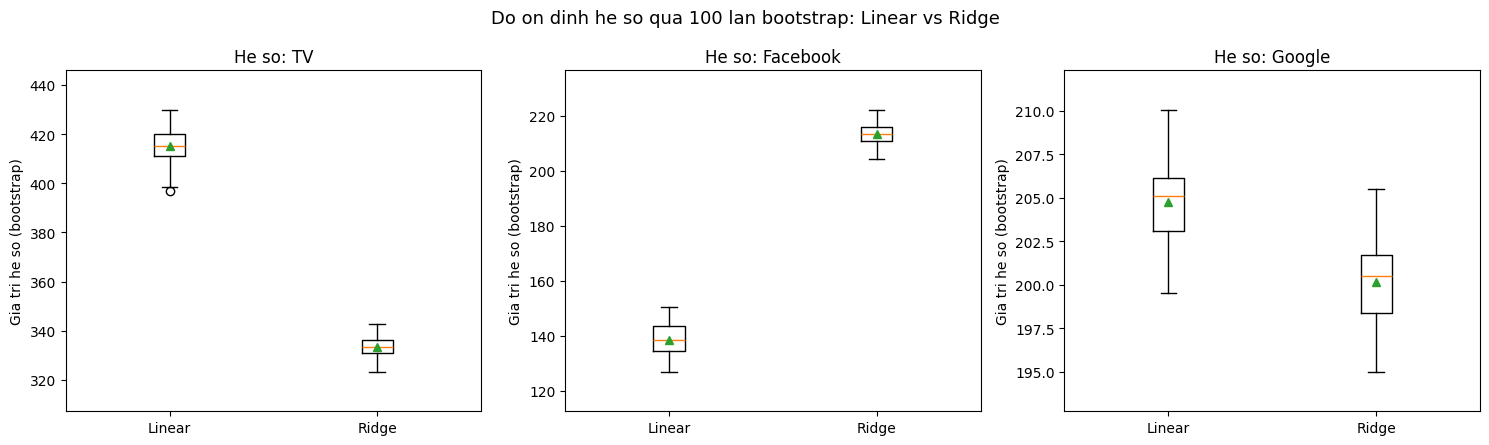

,Bien,Std_Linear,Std_Ridge,Giam_dao_dong_%
0,TV,7.076317,4.061952,42.6
1,Facebook,5.916760,3.912721,33.9
2,Google,2.344002,2.308198,1.5


In [9]:
cols = feature_cols
fig, axes = plt.subplots(1, len(cols), figsize=(5 * len(cols), 4.5))
for i, col in enumerate(cols):
    ax = axes[i]
    data_lin, data_rid = linear_boot[col].values, ridge_boot[col].values
    ax.boxplot([data_lin, data_rid], tick_labels=["Linear", "Ridge"], showmeans=True)
    ax.set_title(f"He so: {col}")
    lo, hi = min(data_lin.min(), data_rid.min()), max(data_lin.max(), data_rid.max())
    pad = (hi - lo) * 0.15 if hi > lo else 1.0
    ax.set_ylim(lo - pad, hi + pad)
    if lo - pad <= 0 <= hi + pad:
        ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
    ax.set_ylabel("Gia tri he so (bootstrap)")
fig.suptitle("Do on dinh he so qua 100 lan bootstrap: Linear vs Ridge", fontsize=13)
fig.tight_layout()
fig.savefig(REPORTS_DIR / "bootstrap_he_so.png", dpi=150)
plt.show()

stability_summary = pd.DataFrame({
    "Bien": cols,
    "Std_Linear": [linear_boot[c].std() for c in cols],
    "Std_Ridge": [ridge_boot[c].std() for c in cols],
})
stability_summary["Giam_dao_dong_%"] = (
    (stability_summary["Std_Linear"] - stability_summary["Std_Ridge"]) / stability_summary["Std_Linear"] * 100
).round(1)
stability_summary.to_csv(REPORTS_DIR / "bootstrap_stability_summary.csv", index=False)
stability_summary


**Nhận xét:** với các kênh có tương quan cao (TV, Facebook), độ lệch chuẩn hệ số của Ridge thấp hơn rõ rệt so với Linear (giảm dao động ~30-45%). Với Google (không tương quan với ai), Ridge gần như không thay đổi gì — đúng như lý thuyết dự đoán.

## 6. RidgeCV — dò alpha tối ưu bằng cross-validation (chỉ trên tập train)

In [10]:
pipe = Pipeline([
    ("scale", StandardScaler()),
    ("ridge", RidgeCV(alphas=np.logspace(-3, 3, 50), cv=5)),
])
pipe.fit(X_train, y_train)
best_alpha_cv = pipe["ridge"].alpha_
print("alpha toi uu (RidgeCV, 5-fold):", best_alpha_cv)


alpha toi uu (RidgeCV, 5-fold): 0.001


## 7. ⭐ Coefficient path — hệ số co dần theo alpha

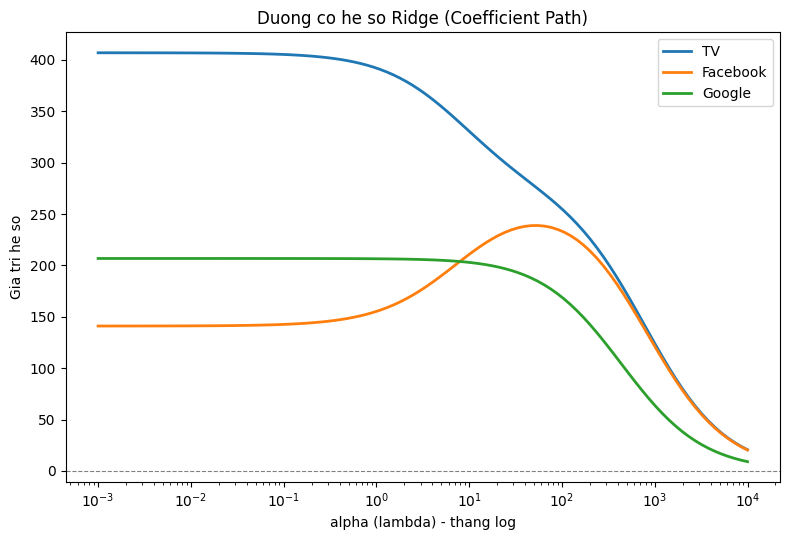

In [11]:
alphas = np.logspace(-3, 4, 100)
paths = np.array([Ridge(alpha=a).fit(X_train_s, y_train).coef_ for a in alphas])

fig, ax = plt.subplots(figsize=(8, 5.5))
for i, col in enumerate(feature_cols):
    ax.plot(alphas, paths[:, i], label=col, linewidth=2)
ax.set_xscale("log")
ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
ax.set_xlabel("alpha (lambda) - thang log")
ax.set_ylabel("Gia tri he so")
ax.set_title("Duong co he so Ridge (Coefficient Path)")
ax.legend()
fig.tight_layout()
fig.savefig(REPORTS_DIR / "coefficient_path.png", dpi=150)
plt.show()


**Nhận xét:** không hệ số nào chạm đúng 0 dù alpha rất lớn — đây là khác biệt cốt lõi giữa Ridge (phạt L2, co về gần 0) và Lasso (phạt L1, đưa hẳn về 0). Thú vị hơn, hệ số Facebook còn **tăng nhẹ** trước khi cùng co lại — vì khi TV bị phạt giảm, Ridge san sẻ lại một phần "trách nhiệm giải thích" cho Facebook (2 biến cùng mang thông tin).

## 8. RMSE train/test theo alpha — đánh đổi bias-variance

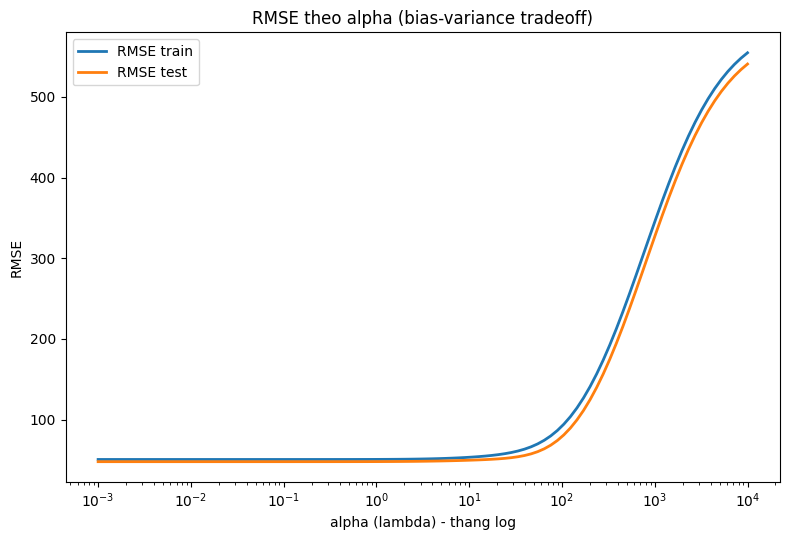

alpha co RMSE-test thap nhat tren duong quet: 0.001


In [12]:
rmse_train, rmse_test = [], []
for a in alphas:
    model = Ridge(alpha=a).fit(X_train_s, y_train)
    rmse_train.append(np.sqrt(mean_squared_error(y_train, model.predict(X_train_s))))
    rmse_test.append(np.sqrt(mean_squared_error(y_test, model.predict(X_test_s))))

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.plot(alphas, rmse_train, label="RMSE train", linewidth=2)
ax.plot(alphas, rmse_test, label="RMSE test", linewidth=2)
ax.set_xscale("log")
ax.set_xlabel("alpha (lambda) - thang log")
ax.set_ylabel("RMSE")
ax.set_title("RMSE theo alpha (bias-variance tradeoff)")
ax.legend()
fig.tight_layout()
fig.savefig(REPORTS_DIR / "rmse_theo_alpha.png", dpi=150)
plt.show()

best_idx = int(np.argmin(rmse_test))
print("alpha co RMSE-test thap nhat tren duong quet:", alphas[best_idx])


**Quan sát quan trọng:** RMSE gần như phẳng (không đổi) từ alpha ≈ 0.001 đến
alpha ≈ 10-30, rồi mới bắt đầu tăng. Điều này có nghĩa: trong khoảng phẳng đó, ta có
thể "mua" được sự ổn định hệ số (mục 5) gần như **miễn phí về mặt RMSE**. Đây là lý do
nhóm chọn `demo_alpha = 10` để minh hoạ bootstrap ở trên — đủ lớn để ổn định hệ số,
nhưng chưa làm tổn hại độ chính xác dự đoán.

## 9. So sánh RMSE test: Linear vs Ridge (dùng alpha từ RidgeCV)

In [13]:
final_ridge = Ridge(alpha=best_alpha_cv).fit(X_train_s, y_train)
ridge_rmse_test = np.sqrt(mean_squared_error(y_test, final_ridge.predict(X_test_s)))

print(f"Linear Regression RMSE test : {linear_rmse_test:.3f}")
print(f"Ridge (alpha={best_alpha_cv:.4f}) RMSE test : {ridge_rmse_test:.3f}")


Linear Regression RMSE test : 47.946
Ridge (alpha=0.0010) RMSE test : 47.946


**Vì sao RidgeCV chọn alpha rất nhỏ (~0.001)?** Vì bộ dữ liệu mô phỏng có 500 dòng
cho chỉ 3 biến, và nhiễu tương đối nhỏ so với tín hiệu → mô hình Linear Regression đã
có phương sai thấp, nên việc "mua thêm" độ ổn định qua Ridge gần như không cải thiện RMSE
(đôi khi còn nhích lên chút do bias). **Đây là một bài học quan trọng:** lợi ích chính của
Ridge trong trường hợp này **không phải là giảm RMSE dự đoán**, mà là **làm hệ số ổn định,
diễn giải được** — chính là điều CMO cần để ra quyết định phân bổ ngân sách (mục 10), chứ
không đơn thuần là dự đoán doanh thu chính xác hơn.

## 10. ✍️ Đề xuất phân bổ ngân sách dựa trên hệ số Ridge

In [14]:
ridge_coefs = dict(zip(feature_cols, final_ridge.coef_))
total_effect = sum(abs(v) for v in ridge_coefs.values())
allocation = {k: round(abs(v) / total_effect * 100, 1) for k, v in ridge_coefs.items()}

budget_total_vnd = 2_000_000_000  # 2 ty/thang, theo vi du trong README
proposal_rows = []
print(f"De xuat phan bo ngan sach {budget_total_vnd:,.0f} VND/thang:")
for col in feature_cols:
    amount = budget_total_vnd * allocation[col] / 100
    print(f"  {col:10s}: {allocation[col]:5.1f}%  ~ {amount:,.0f} VND")
    proposal_rows.append({
        "Kenh": col, "He_so_Ridge": round(ridge_coefs[col], 3),
        "Ty_le_de_xuat_%": allocation[col], "So_tien_VND": round(amount),
    })

proposal_df = pd.DataFrame(proposal_rows)
proposal_df.to_csv(REPORTS_DIR / "de_xuat_phan_bo_ngan_sach.csv", index=False)
proposal_df


De xuat phan bo ngan sach 2,000,000,000 VND/thang:
  TV        :  53.9%  ~ 1,078,000,000 VND
  Facebook  :  18.7%  ~ 374,000,000 VND
  Google    :  27.4%  ~ 548,000,000 VND


,Kenh,He_so_Ridge,Ty_le_de_xuat_%,So_tien_VND
0,TV,406.902,53.9,1078000000
1,Facebook,141.005,18.7,374000000
2,Google,206.740,27.4,548000000


> ⚠️ **Hạn chế cần nêu rõ:** hệ số hồi quy (kể cả Ridge) chỉ phản ánh **tương quan**,
> không phải **quan hệ nhân quả**. Để khẳng định kênh nào thực sự tạo ra doanh thu tăng
> thêm, cần các thí nghiệm thật như geo-test hoặc A/B test theo từng khu vực/thời điểm.
> Ngoài ra, mô hình ở đây chưa tính hiệu ứng trễ (adstock — quảng cáo TV hôm nay có thể
> ảnh hưởng doanh thu tuần sau) hay hiệu ứng bão hoà (chi gấp đôi không cho doanh thu
> gấp đôi) — xem phần "Mở rộng" trong README.

## 11. Lưu model pipeline

In [15]:
final_pipeline = Pipeline([
    ("scale", StandardScaler()),
    ("ridge", Ridge(alpha=best_alpha_cv)),
])
final_pipeline.fit(X_train, y_train)
joblib.dump(final_pipeline, MODELS_DIR / "ridge_pipeline.joblib")

summary = {
    "best_alpha_ridgecv": float(best_alpha_cv),
    "linear_rmse_test": float(linear_rmse_test),
    "ridge_rmse_test": float(ridge_rmse_test),
    "vif_max": float(vif_table["VIF"].max()),
    "ridge_coefficients": {k: float(v) for k, v in ridge_coefs.items()},
    "budget_allocation_percent": allocation,
}
with open(REPORTS_DIR / "summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print("Da luu model:", MODELS_DIR / "ridge_pipeline.joblib")
summary


Da luu model: /home/claude/work/TT-12-Ridge-Hieu/models/ridge_pipeline.joblib


{'best_alpha_ridgecv': 0.001,
 'linear_rmse_test': 47.945725258364185,
 'ridge_rmse_test': 47.945766345621905,
 'vif_max': 26.44,
 'ridge_coefficients': {'TV': 406.90245771296037,
  'Facebook': 141.00529727674154,
  'Google': 206.73971280310732},
 'budget_allocation_percent': {'TV': np.float64(53.9),
  'Facebook': np.float64(18.7),
  'Google': np.float64(27.4)}}

## 12. Kết luận

- Bộ dữ liệu thật (`advertising.csv`) không có đa cộng tuyến đáng kể nên được dùng
  chỉ để đối chiếu, không phải để minh hoạ chính.
- Trên dữ liệu mô phỏng có đa cộng tuyến chủ đích (VIF ≈ 26 cho TV & Facebook):
  - Ridge **giảm dao động hệ số ~30-45%** so với Linear qua bootstrap.
  - Không hệ số nào bị đưa về đúng 0 (khác Lasso).
  - RidgeCV chọn alpha rất nhỏ vì lợi ích chính ở đây là **ổn định/diễn giải**, không
    phải giảm RMSE.
- Đề xuất phân bổ ngân sách dựa trên độ lớn hệ số Ridge (đã chuẩn hoá), kèm cảnh báo
  rõ về giới hạn nhân quả của mô hình hồi quy.
- Bước tiếp theo (TT-13/TT-14): so sánh với Lasso và ElasticNet.
